# Twitter Sentiment Analysis - ML Experimentation Notebook

This notebook documents the experimentation process used to build a sentiment classification model on tweets.

The objective is not to develop a state-of-the-art NLP model, but to build a clean, reproducible and explainable Machine Learning pipeline. The final model is intended to be reused later in a FastAPI application.

Main steps:

1. Load and inspect the dataset.
2. Analyze missing values and class distributions.
3. Check potential train-validation overlap.
4. Compare simple and robust ML configurations.
5. Select a final model based on cross-validation.
6. Evaluate the final model on the provided validation set and on a filtered validation set without train overlap.
7. Save the trained pipeline and experiment results.


## Imports and global configuration

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, ConfusionMatrixDisplay, f1_score

from sentiment_analysis.config import (
    SEED,
    TRAINING_DATA_PATH,
    VALIDATION_DATA_PATH,
    FINAL_MODEL_PATH,
    FINAL_METADATA_PATH,
    EXPERIMENT_SUMMARY_PATH,
    MISCLASSIFIED_EXAMPLES_PATH,
    LABEL_NAMES,
)

from sentiment_analysis.data import (
    load_twitter_dataset,
    drop_missing_texts,
    fill_missing_texts,
    get_features_and_target,
)

from sentiment_analysis.models import (
    build_logistic_regression_pipeline,
    build_linear_svc_pipeline,
)

from sentiment_analysis.evaluation import (
    run_experiments,
    summarize_experiment_results,
    train_and_evaluate_pipeline,
    get_misclassified_examples,
)

from sentiment_analysis.overlap import (
    analyze_text_overlap_detailed,
    remove_validation_overlap_with_train,
    compare_class_distributions,
)

from sentiment_analysis.persistence import (
    save_model,
    load_model,
    save_metadata,
    save_dataframe_csv,
)

from sentiment_analysis.utils import set_seed


## Reproducibility setup

A fixed random seed is used to make the experiments as reproducible as possible.

The seed controls Python's random module, NumPy, and scikit-learn components that expose a `random_state` parameter. Some runtime metadata, such as execution timestamps or execution time, can still vary between runs.


In [2]:
set_seed(SEED)


## Utility functions

The following functions centralize repeated operations used across experiments:

- cross-validation with macro F1-score;
- final training and validation evaluation;
- visualization of classification reports and confusion matrices;
- duplicate and overlap analysis;
- extraction of misclassified examples.

Keeping these operations in functions makes the notebook easier to read and prepares the code for future modularization into Python scripts.


In [3]:
def visualize_results(
    result: dict,
    y_val: pd.Series,
    label_names: dict[int, str],
) -> None:
    """Display main metrics, classification report and confusion matrix."""
    labels = sorted(label_names.keys())
    target_names = [label_names[label] for label in labels]

    print(f"{result['exp_group']} - Best config: {result['exp_name']}")
    print(f"Avg CV F1 macro: {result['cv_mean_f1_macro']:.4f}")
    print(f"Train F1 macro: {result['train_f1_macro']:.4f}")
    print(f"Val F1 macro: {result['val_f1_macro']:.4f}")
    print(f"Train time (sec): {result['train_time_sec']:.4f}")
    print(f"Val time (sec): {result['eval_time_sec']:.4f}")

    print(classification_report(
        y_val,
        result["y_val_pred"],
        labels=labels,
        target_names=target_names,
    ))

    ConfusionMatrixDisplay.from_predictions(
        y_val,
        result["y_val_pred"],
        labels=labels,
        display_labels=target_names,
        xticks_rotation=45,
        cmap="Blues",
    )

    plt.title(f"Confusion matrix - {result['exp_name']}")
    plt.tight_layout()
    plt.show()


## Data loading and target encoding

The dataset contains tweet texts, sentiment labels and associated entities.

For this first version, only the tweet text is used as model input. The `entity` column is kept for analysis and error inspection, but it is not used as a feature. This keeps the model simple and focused on text-based sentiment classification.

The target labels are encoded as integers to be compatible with scikit-learn models.


In [4]:
# Load csv data
twitter_train_data = load_twitter_dataset(TRAINING_DATA_PATH)
twitter_val_data = load_twitter_dataset(VALIDATION_DATA_PATH)

label_names = LABEL_NAMES

pd.set_option('display.max_colwidth', None) # To display the full content of the column
twitter_train_data.tail(5)

,Tweet_ID,entity,sentiment,Tweet_content
74677,9200,Nvidia,1,Just realized that the Windows partition of my Mac is like 6 years behind Nvidia drivers and I have no idea how I did not notice
74678,9200,Nvidia,1,Just realized that my Mac window partition is 6 years behind on Nvidia drivers and I have no idea how I didn't notice
74679,9200,Nvidia,1,Just realized the windows partition of my Mac is now 6 years behind on Nvidia drivers and I have no idea how he didn’t notice
74680,9200,Nvidia,1,Just realized between the windows partition of my Mac is like being 6 years behind on Nvidia drivers and cars I have no fucking idea how I ever didn ’ t notice
74681,9200,Nvidia,1,Just like the windows partition of my Mac is like 6 years behind on its drivers So you have no idea how I didn’t notice


## Exploratory data analysis

Before training models, the dataset is inspected to understand class distribution and missing values.

This step helps justify the choice of evaluation metric and preprocessing strategy. Since the task is multi-class classification and the classes are not perfectly balanced, macro F1-score is used as the main metric.


In [5]:
# Class distributions
class_distribution_train = twitter_train_data["sentiment"].value_counts().sort_index()
class_distribution_pct_train = (
    twitter_train_data["sentiment"].value_counts(normalize=True).sort_index() * 100
)

class_distribution_val = twitter_val_data["sentiment"].value_counts().sort_index()
class_distribution_pct_val = (
    twitter_val_data["sentiment"].value_counts(normalize=True).sort_index() * 100
)

labels = sorted(label_names.keys())

pd.DataFrame({
    "sentiment": [label_names[label] for label in labels],
    "count_train": class_distribution_train.reindex(labels, fill_value=0).values,
    "percentage_train": class_distribution_pct_train.reindex(labels, fill_value=0).round(2).values,
    "count_val": class_distribution_val.reindex(labels, fill_value=0).values,
    "percentage_val": class_distribution_pct_val.reindex(labels, fill_value=0).round(2).values,
})


,sentiment,count_train,percentage_train,count_val,percentage_val
0,Negative,22542,30.18,266,26.6
1,Positive,20832,27.89,277,27.7
2,Neutral,18318,24.53,285,28.5
3,Irrelevant,12990,17.39,172,17.2


## Data quality checks: missing values and train-validation overlap

In [6]:
# NaN distribution
features = twitter_train_data.columns
summary = pd.DataFrame(index=["Train", "Validation"], columns=features)

for name, df in [("Train", twitter_train_data), ("Validation", twitter_val_data)]:
    for feature in features:
        n_nan = df[feature].isna().sum()
        pct_nan = 100 * n_nan / len(df)
        summary.loc[name, feature] = f"{n_nan} ({pct_nan:.2f}%)"

display(summary)

,Tweet_ID,entity,sentiment,Tweet_content
Train,0 (0.00%),0 (0.00%),0 (0.00%),686 (0.92%)
Validation,0 (0.00%),0 (0.00%),0 (0.00%),0 (0.00%)


In [7]:
# Remove rows where NaN for Tweet_content
twitter_train_data_drop_na = drop_missing_texts(twitter_train_data)
# Fill with '' rows where NaN for Tweet content
twitter_train_data_fill_na = fill_missing_texts(twitter_train_data)

X_val, y_val = get_features_and_target(twitter_val_data)

# In this validation dataset, no NaN, but this assert could be triggered if the dataset changed
assert twitter_val_data["Tweet_content"].isna().sum() == 0

## Train-validation overlap analysis

The provided validation set is analyzed for possible overlap with the training set.

This is important because duplicated texts between train and validation can make validation performance overly optimistic. The overlap is computed using a simple normalized version of the tweet text: lowercase and stripped whitespace.

This analysis is used only to interpret the reliability of the validation score, not to tune the model.



In [8]:
# Overlap analysis
overlap_results_detailed, overlap_examples = analyze_text_overlap_detailed(
    train_df=twitter_train_data_drop_na,
    val_df=twitter_val_data,
)

pd.DataFrame([overlap_results_detailed])

columns_to_display = [
    "Tweet_ID",
    "entity",
    "Tweet_content",
    "sentiment",
    "train_labels_for_same_text",
    "label_seen_with_same_text_in_train",
]

display(overlap_examples[columns_to_display].head(10))


,Tweet_ID,entity,Tweet_content,sentiment,train_labels_for_same_text,label_seen_with_same_text_in_train
0,3364,Facebook,"I mentioned on Facebook that I was struggling for motivation to go for a run the other day, which has been translated by Tom’s great auntie as ‘Hayley can’t get out of bed’ and told to his grandma, who now thinks I’m a lazy, terrible person 🤣",3,[3],True
1,352,Amazon,BBC News - Amazon boss Jeff Bezos rejects claims company acted like a 'drug dealer' bbc.co.uk/news/av/busine…,2,[2],True
3,4371,CS-GO,"CSGO matchmaking is so full of closet hacking, it's a truly awful game.",0,[0],True
4,4433,Google,Now the President is slapping Americans in the face that he really did commit an unlawful act after his acquittal! From Discover on Google vanityfair.com/news/2020/02/t…,2,[2],True
5,6273,FIFA,"Hi @EAHelp I’ve had Madeleine McCann in my cellar for the past 13 years and the little sneaky thing just escaped whilst I was loading up some fifa points, she took my card and I’m having to use my paypal account but it isn’t working, can you help me resolve it please?",0,[0],True
8,1107,AssassinsCreed,my ass still knee-deep in Assassins Creed Odyssey with no way out anytime soon lmao,1,[1],True
9,2069,CallOfDuty,FIX IT JESUS ! Please FIX IT ! What In the world is going on here. @PlayStation @AskPlayStation @Playstationsup @Treyarch @CallofDuty negative 345 silver wolf error code pic.twitter.com/ziRyhrf59Q,0,[0],True
12,11783,Verizon,"@FredTJoseph hey fred, Comcast cut the cable and now Verizon stays calling me to shut that too pic.twitter.com/CPWSrmueDg",0,[0],True
13,4286,CS-GO,CSGO WIngman (Im Silver dont bully) twitch.tv/lprezh,2,[2],True
14,8431,NBA2K,@NBA2K game sucks... down by 2 with 38 seconds left and my team intentionally fouls,0,[0],True


### Overlap analysis interpretation

A significant portion of the validation set is also present in the training set. This means that the validation score computed on the full validation set may be optimistic.

To control this risk, the final model will also be evaluated on a filtered validation set where texts already present in the training set are removed.

If the performance remains high on this filtered subset, it provides stronger evidence that the model is not only memorizing duplicated tweets.


In [9]:
twitter_val_data_no_overlap = remove_validation_overlap_with_train(
    train_df=twitter_train_data_drop_na,
    val_df=twitter_val_data,
)

print(f"Original validation size: {len(twitter_val_data)}")
print(f"Validation size without train overlap: {len(twitter_val_data_no_overlap)}")
print(f"Removed validation rows: {len(twitter_val_data) - len(twitter_val_data_no_overlap)}")

Original validation size: 1000
Validation size without train overlap: 483
Removed validation rows: 517


In [10]:
val_distribution_comparison = compare_class_distributions(
    original_df=twitter_val_data,
    filtered_df=twitter_val_data_no_overlap,
    label_col="sentiment",
    label_names=label_names,
)

## Experiment 1: missing value strategy

This experiment compares two simple strategies for missing tweet texts:

1. Dropping rows where `Tweet_content` is missing.
2. Filling missing tweet texts with an empty string.

The comparison is performed using cross-validation on the training set only. The validation set is kept for final evaluation of the selected configuration.


In [11]:
X_train_drop_na, y_train_drop_na = get_features_and_target(twitter_train_data_drop_na)
X_train_fill_na, y_train_fill_na = get_features_and_target(twitter_train_data_fill_na)
X_val, y_val = get_features_and_target(twitter_val_data)

experiments_nan = [
    {
        "name": "Drop NaN",
        "pipeline": build_logistic_regression_pipeline(
            max_iter=1000,
            class_weight="balanced",
            random_state=SEED,
        ),
        "X_train": X_train_drop_na,
        "y_train": y_train_drop_na,
        "X_val": X_val,
        "y_val": y_val,
    },
    {
        "name": "Fill NaN",
        "pipeline": build_logistic_regression_pipeline(
            max_iter=1000,
            class_weight="balanced",
            random_state=SEED,
        ),
        "X_train": X_train_fill_na,
        "y_train": y_train_fill_na,
        "X_val": X_val,
        "y_val": y_val,
    },
]


In [12]:
results_nan = run_experiments(
    experiments=experiments_nan,
    exp_group="NaN",
    seed=SEED,
)

display(
    summarize_experiment_results(results_nan).sort_values(
        by=["cv_mean_f1_macro", "cv_mean_time_per_fold_sec"],
        ascending=[False, True],
    )
)

,experiment_group,experiment_name,cv_mean_f1_macro,cv_std_f1_macro,cv_mean_time_per_fold_sec,fold_scores
0,NaN,Drop NaN,0.791921,0.001406,31.030764,"[0.7908163222867193, 0.7904466175045624, 0.7933387496168951, 0.7938821588381788, 0.7911233588927089]"
1,NaN,Fill NaN,0.786855,0.004654,29.723058,"[0.7947395451346755, 0.7852210911388505, 0.7805176329433912, 0.7856159009896991, 0.788179429254144]"


In [13]:
best_result_nan = max(
    results_nan,
    key=lambda result: result["cv_mean_f1_macro"]
)

final_eval_nan = train_and_evaluate_pipeline(
    pipeline=best_result_nan["pipeline"],
    X_train=best_result_nan["X_train"],
    y_train=best_result_nan["y_train"],
    X_val=best_result_nan["X_val"],
    y_val=best_result_nan["y_val"],
)

best_result_nan = {
    **best_result_nan,
    **final_eval_nan,
}

NaN - Best config: Drop NaN
Avg CV F1 macro: 0.7919
Train F1 macro: 0.8661
Val F1 macro: 0.9141
Train time (sec): 29.1640
Val time (sec): 0.0135
              precision    recall  f1-score   support

    Negative       0.92      0.91      0.92       266
    Positive       0.90      0.91      0.91       277
     Neutral       0.95      0.91      0.93       285
  Irrelevant       0.88      0.94      0.90       172

    accuracy                           0.92      1000
   macro avg       0.91      0.92      0.91      1000
weighted avg       0.92      0.92      0.92      1000



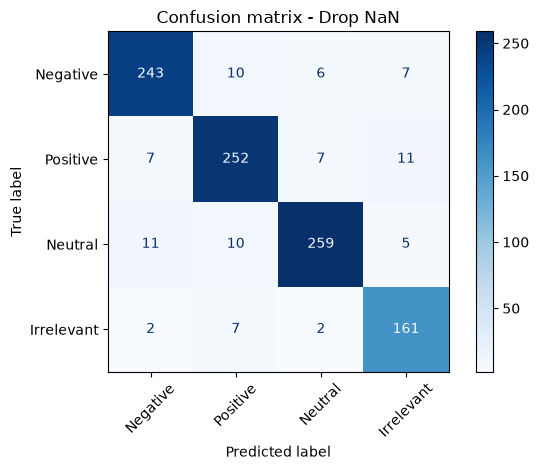

In [14]:
visualize_results(result=best_result_nan, y_val=best_result_nan["y_val"], label_names=label_names)

In [15]:
# Clean data to use for the next exps
X_train, y_train = get_features_and_target(twitter_train_data_drop_na)
X_val, y_val = get_features_and_target(twitter_val_data)

## Experiment 2: class weighting

This experiment evaluates whether using `class_weight="balanced"` improves macro F1-score.

Class weighting can help when classes are imbalanced because it penalizes mistakes on minority classes more strongly during training.


In [16]:
experiments_class_weight = [
    {
        "name": "No class weight",
        "pipeline": build_logistic_regression_pipeline(
            max_iter=1000,
            class_weight=None,
            random_state=SEED,
        ),
        "X_train": X_train,
        "y_train": y_train,
        "X_val": X_val,
        "y_val": y_val,
    },
    {
        "name": "With balanced class weight",
        "pipeline": build_logistic_regression_pipeline(
            max_iter=1000,
            class_weight="balanced",
            random_state=SEED,
        ),
        "X_train": X_train,
        "y_train": y_train,
        "X_val": X_val,
        "y_val": y_val,
    },
]


In [17]:
results_class_weight = run_experiments(
    experiments=experiments_class_weight,
    exp_group="Class weight",
    seed=SEED,
)

display(
    summarize_experiment_results(results_class_weight).sort_values(
        by=["cv_mean_f1_macro", "cv_mean_time_per_fold_sec"],
        ascending=[False, True],
    )
)

,experiment_group,experiment_name,cv_mean_f1_macro,cv_std_f1_macro,cv_mean_time_per_fold_sec,fold_scores
1,Class weight,With balanced class weight,0.791921,0.001406,30.705356,"[0.7908163222867193, 0.7904466175045624, 0.7933387496168951, 0.7938821588381788, 0.7911233588927089]"
0,Class weight,No class weight,0.787639,0.001996,30.496771,"[0.7860820481731778, 0.7881004190766285, 0.7904282060953013, 0.7888017039556006, 0.7847838154996664]"


In [18]:
best_result_class_weight = max(
    results_class_weight,
    key=lambda result: result["cv_mean_f1_macro"]
)

final_eval_class_weight = train_and_evaluate_pipeline(
    pipeline=best_result_class_weight["pipeline"],
    X_train=best_result_class_weight["X_train"],
    y_train=best_result_class_weight["y_train"],
    X_val=best_result_class_weight["X_val"],
    y_val=best_result_class_weight["y_val"],
)

best_result_class_weight = {
    **best_result_class_weight,
    **final_eval_class_weight,
}

Class weight - Best config: With balanced class weight
Avg CV F1 macro: 0.7919
Train F1 macro: 0.8661
Val F1 macro: 0.9141
Train time (sec): 28.8566
Val time (sec): 0.0134
              precision    recall  f1-score   support

    Negative       0.92      0.91      0.92       266
    Positive       0.90      0.91      0.91       277
     Neutral       0.95      0.91      0.93       285
  Irrelevant       0.88      0.94      0.90       172

    accuracy                           0.92      1000
   macro avg       0.91      0.92      0.91      1000
weighted avg       0.92      0.92      0.92      1000



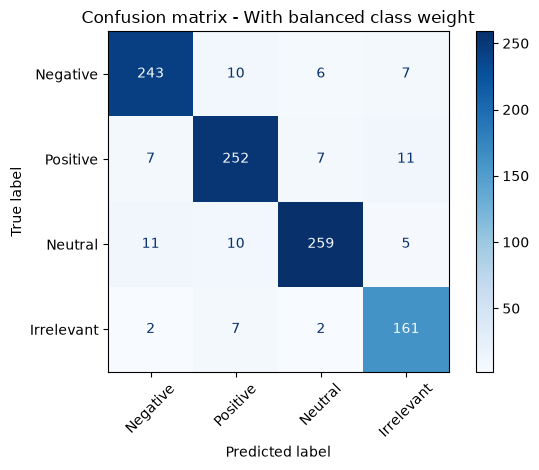

In [19]:
visualize_results(result=best_result_class_weight, y_val=best_result_class_weight["y_val"], label_names=label_names)

## Experiment 3: text preprocessing

This experiment compares simple TF-IDF preprocessing choices:

- default unigram representation;
- English stopword removal;
- unigrams and bigrams;
- stopword removal combined with unigrams and bigrams.

The objective is to improve the representation while keeping the pipeline simple and explainable.


In [20]:
experiments_preprocessing = [
    {
        "name": "Baseline",
        "pipeline": build_logistic_regression_pipeline(
            max_iter=1000,
            class_weight="balanced",
            random_state=SEED,
        ),
        "X_train": X_train,
        "y_train": y_train,
        "X_val": X_val,
        "y_val": y_val,
    },
    {
        "name": "With English stopwords removal",
        "pipeline": build_logistic_regression_pipeline(
            max_iter=1000,
            class_weight="balanced",
            random_state=SEED,
            stop_words="english",
        ),
        "X_train": X_train,
        "y_train": y_train,
        "X_val": X_val,
        "y_val": y_val,
    },
    {
        "name": "With unigrams and bigrams",
        "pipeline": build_logistic_regression_pipeline(
            max_iter=1000,
            class_weight="balanced",
            random_state=SEED,
            ngram_range=(1, 2),
        ),
        "X_train": X_train,
        "y_train": y_train,
        "X_val": X_val,
        "y_val": y_val,
    },
    {
        "name": "With English stopwords removal, and unigrams and bigrams",
        "pipeline": build_logistic_regression_pipeline(
            max_iter=1000,
            class_weight="balanced",
            random_state=SEED,
            stop_words="english",
            ngram_range=(1, 2),
        ),
        "X_train": X_train,
        "y_train": y_train,
        "X_val": X_val,
        "y_val": y_val,
    },
]


In [21]:
results_preprocessing = run_experiments(
    experiments=experiments_preprocessing,
    exp_group="Preprocessing",
    seed=SEED,
)

display(
    summarize_experiment_results(results_preprocessing).sort_values(
        by=["cv_mean_f1_macro", "cv_mean_time_per_fold_sec"],
        ascending=[False, True],
    )
)

,experiment_group,experiment_name,cv_mean_f1_macro,cv_std_f1_macro,cv_mean_time_per_fold_sec,fold_scores
2,Preprocessing,With unigrams and bigrams,0.877913,0.002193,46.219860,"[0.8780295865096761, 0.8758261670995537, 0.8820648449114096, 0.8766504821433432, 0.8769964076433999]"
3,Preprocessing,"With English stopwords removal, and unigrams and bigrams",0.874281,0.002134,43.842525,"[0.8739623744741982, 0.8750878357574209, 0.8777241599644062, 0.8712104296705304, 0.873422516198626]"
1,Preprocessing,With English stopwords removal,0.795883,0.001727,25.952280,"[0.7962371463550908, 0.7968263921403406, 0.7980992236010783, 0.7929407955924486, 0.7953114169056906]"
0,Preprocessing,Baseline,0.791921,0.001406,30.761840,"[0.7908163222867193, 0.7904466175045624, 0.7933387496168951, 0.7938821588381788, 0.7911233588927089]"


In [22]:
best_result_preprocessing = max(
    results_preprocessing,
    key=lambda result: result["cv_mean_f1_macro"]
)

final_eval_preprocessing = train_and_evaluate_pipeline(
    pipeline=best_result_preprocessing["pipeline"],
    X_train=best_result_preprocessing["X_train"],
    y_train=best_result_preprocessing["y_train"],
    X_val=best_result_preprocessing["X_val"],
    y_val=best_result_preprocessing["y_val"],
)

best_result_preprocessing = {
    **best_result_preprocessing,
    **final_eval_preprocessing,
}

Preprocessing - Best config: With unigrams and bigrams
Avg CV F1 macro: 0.8779
Train F1 macro: 0.9568
Val F1 macro: 0.9761
Train time (sec): 54.8923
Val time (sec): 0.0307
              precision    recall  f1-score   support

    Negative       0.98      0.98      0.98       266
    Positive       0.97      0.97      0.97       277
     Neutral       0.98      0.98      0.98       285
  Irrelevant       0.98      0.97      0.98       172

    accuracy                           0.98      1000
   macro avg       0.98      0.98      0.98      1000
weighted avg       0.98      0.98      0.98      1000



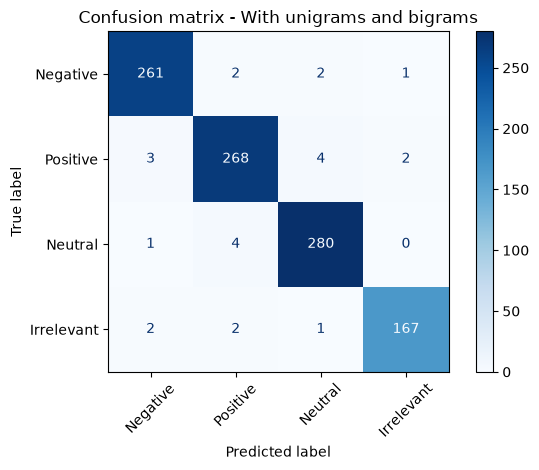

In [23]:
visualize_results(result=best_result_preprocessing, y_val=best_result_preprocessing["y_val"], label_names=label_names)

## Experiment 4: model comparison

This experiment compares two classical linear models for text classification:

- Logistic Regression;
- Linear Support Vector Classification.

Both models are strong baselines for TF-IDF features. The goal is to select a robust and efficient model rather than introduce unnecessary model complexity.


In [24]:
experiments_models = [
    {
        "name": "Logistic Regression (+TF-IDF)",
        "pipeline": build_logistic_regression_pipeline(
            max_iter=1000,
            class_weight="balanced",
            random_state=SEED,
            ngram_range=(1, 2),
        ),
        "X_train": X_train,
        "y_train": y_train,
        "X_val": X_val,
        "y_val": y_val,
    },
    {
        "name": "Linear SVM (+TF-IDF)",
        "pipeline": build_linear_svc_pipeline(
            max_iter=1000,
            class_weight="balanced",
            random_state=SEED,
            ngram_range=(1, 2),
        ),
        "X_train": X_train,
        "y_train": y_train,
        "X_val": X_val,
        "y_val": y_val,
    },
]



In [25]:
results_models = run_experiments(
    experiments=experiments_models,
    exp_group="Models",
    seed=SEED,
)

display(
    summarize_experiment_results(results_models).sort_values(
        by=["cv_mean_f1_macro", "cv_mean_time_per_fold_sec"],
        ascending=[False, True],
    )
)

,experiment_group,experiment_name,cv_mean_f1_macro,cv_std_f1_macro,cv_mean_time_per_fold_sec,fold_scores
1,Models,Linear SVM (+TF-IDF),0.939284,0.000760,6.515447,"[0.9388172528445984, 0.9381835354457838, 0.9402816348533971, 0.9391797404584339, 0.9399554077000698]"
0,Models,Logistic Regression (+TF-IDF),0.877913,0.002193,46.757225,"[0.8780295865096761, 0.8758261670995537, 0.8820648449114096, 0.8766504821433432, 0.8769964076433999]"


In [26]:
best_result_models = max(
    results_models,
    key=lambda result: result["cv_mean_f1_macro"]
)

final_eval_models = train_and_evaluate_pipeline(
    pipeline=best_result_models["pipeline"],
    X_train=best_result_models["X_train"],
    y_train=best_result_models["y_train"],
    X_val=best_result_models["X_val"],
    y_val=best_result_models["y_val"],
)

best_result_models = {
    **best_result_models,
    **final_eval_models,
}

Models - Best config: Linear SVM (+TF-IDF)
Avg CV F1 macro: 0.9393
Train F1 macro: 0.9787
Val F1 macro: 0.9878
Train time (sec): 7.6928
Val time (sec): 0.0323
              precision    recall  f1-score   support

    Negative       1.00      0.99      0.99       266
    Positive       0.98      0.99      0.98       277
     Neutral       0.99      0.99      0.99       285
  Irrelevant       0.98      0.99      0.99       172

    accuracy                           0.99      1000
   macro avg       0.99      0.99      0.99      1000
weighted avg       0.99      0.99      0.99      1000



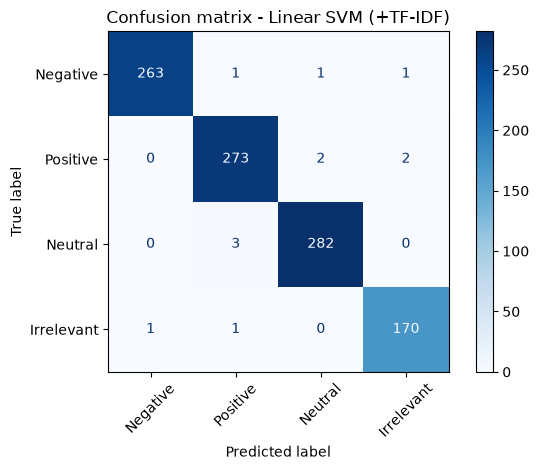

In [27]:
visualize_results(result=best_result_models, y_val=best_result_models["y_val"], label_names=label_names)

## Final model selection

The final configuration is mainly selected based on cross-validation results on the training set.

The validation set is used as an external check to evaluate the selected configurations. To reduce over-interpretation of the provided validation set, an additional evaluation is performed on a filtered validation subset without train overlap.


In [28]:
final_candidates = [
    best_result_nan,
    best_result_class_weight,
    best_result_preprocessing,
    best_result_models,
]

summary_final_results = pd.DataFrame([
    {
        "experiment_group": result.get("exp_group", "Unknown"),
        "experiment_name": result["exp_name"],
        "cv_mean_f1_macro": result["cv_mean_f1_macro"],
        "cv_std_f1_macro": result["cv_std_f1_macro"],
        "train_f1_macro": result["train_f1_macro"],
        "val_f1_macro": result["val_f1_macro"],
        "train_time_sec": result["train_time_sec"],
        "eval_time_sec": result["eval_time_sec"],
    }
    for result in final_candidates
])

display(
    summary_final_results.sort_values(
        by=["cv_mean_f1_macro", "val_f1_macro"],
        ascending=False
    )
)


,experiment_group,experiment_name,cv_mean_f1_macro,cv_std_f1_macro,train_f1_macro,val_f1_macro,train_time_sec,eval_time_sec
3,Models,Linear SVM (+TF-IDF),0.939284,0.000760,0.978707,0.987804,7.692809,0.032325
2,Preprocessing,With unigrams and bigrams,0.877913,0.002193,0.956813,0.976062,54.892299,0.030710
0,NaN,Drop NaN,0.791921,0.001406,0.866124,0.914085,29.163998,0.013509
1,Class weight,With balanced class weight,0.791921,0.001406,0.866124,0.914085,28.856592,0.013414


Selected final model: Linear SVM (+TF-IDF)
Validation F1 macro: 0.9878
Models - Best config: Linear SVM (+TF-IDF)
Avg CV F1 macro: 0.9393
Train F1 macro: 0.9787
Val F1 macro: 0.9878
Train time (sec): 7.6928
Val time (sec): 0.0323
              precision    recall  f1-score   support

    Negative       1.00      0.99      0.99       266
    Positive       0.98      0.99      0.98       277
     Neutral       0.99      0.99      0.99       285
  Irrelevant       0.98      0.99      0.99       172

    accuracy                           0.99      1000
   macro avg       0.99      0.99      0.99      1000
weighted avg       0.99      0.99      0.99      1000



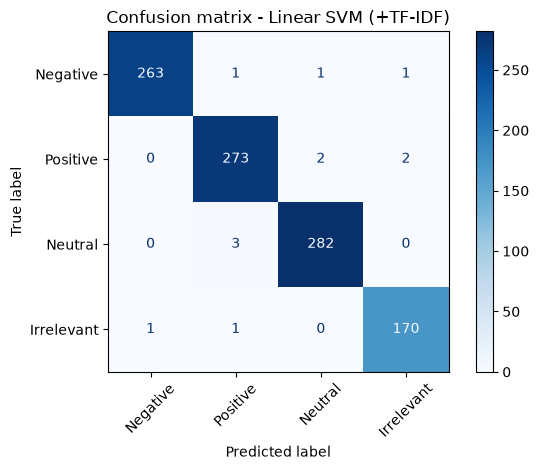

In [29]:
# The final model is selected from the model comparison step because
# previous experiments were used to define preprocessing and training choices.
best_final_result = best_result_models

print(f"Selected final model: {best_final_result['exp_name']}")
print(f"Validation F1 macro: {best_final_result['val_f1_macro']:.4f}")
visualize_results(result=best_final_result, y_val=best_final_result["y_val"], label_names=label_names)

## Robustness check: validation without train overlap

Because the original validation set contains duplicated texts from the training set, the final model is also evaluated on a filtered validation set.

This filtered set removes validation examples whose normalized text is already present in the training set. The resulting score is a more conservative estimate of model performance on unseen tweet texts.


Validation F1 macro without train overlap: 0.9797
              precision    recall  f1-score   support

    Negative       0.99      0.98      0.98        92
    Positive       0.96      0.98      0.97       133
     Neutral       0.98      0.98      0.98       171
  Irrelevant       0.99      0.98      0.98        87

    accuracy                           0.98       483
   macro avg       0.98      0.98      0.98       483
weighted avg       0.98      0.98      0.98       483



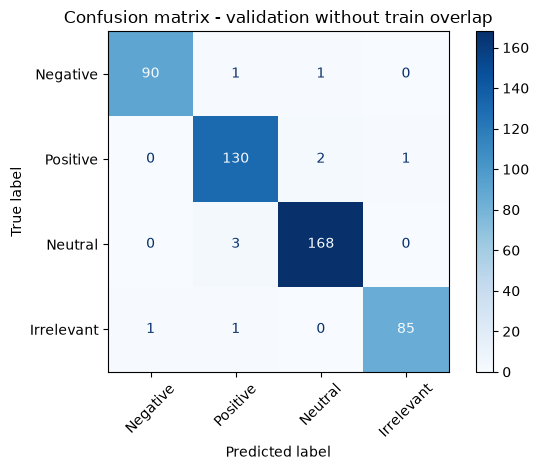

In [30]:
# Evaluate on validation dataset without overlap
X_val_no_overlap, y_val_no_overlap = get_features_and_target(twitter_val_data_no_overlap)

y_pred_val_no_overlap = best_final_result["trained_pipeline"].predict(X_val_no_overlap)

val_no_overlap_f1_macro = f1_score(
    y_val_no_overlap,
    y_pred_val_no_overlap,
    average="macro",
)

print(f"Validation F1 macro without train overlap: {val_no_overlap_f1_macro:.4f}")

print(classification_report(
    y_val_no_overlap,
    y_pred_val_no_overlap,
    labels=sorted(label_names.keys()),
    target_names=[label_names[i] for i in sorted(label_names.keys())],
))

ConfusionMatrixDisplay.from_predictions(
    y_val_no_overlap,
    y_pred_val_no_overlap,
    labels=sorted(label_names.keys()),
    display_labels=[label_names[i] for i in sorted(label_names.keys())],
    xticks_rotation=45,
    cmap="Blues",
)

plt.title("Confusion matrix - validation without train overlap")
plt.tight_layout()
plt.show()


### Robustness check interpretation

The model keeps a high macro F1-score on the validation subset without train overlap.

This suggests that the model performance is not only caused by exact duplicate memorization. However, the filtered validation set is smaller than the original one, so the result should be interpreted as a robustness check rather than a definitive benchmark.


## Error analysis

Misclassified validation examples are extracted to better understand the model's limitations.

This step is useful because aggregate metrics such as F1-score do not explain which examples are difficult or ambiguous. Reviewing errors helps identify possible issues such as ambiguous sentiment, missing context, sarcasm, or noisy labels.


In [31]:
misclassified_examples = get_misclassified_examples(
    val_df=twitter_val_data,
    y_true=y_val,
    y_pred=best_final_result["y_val_pred"],
    label_names=label_names,
)

print(f"Number of misclassified examples: {len(misclassified_examples)}")
display(misclassified_examples)


Number of misclassified examples: 12


,Tweet_ID,entity,Tweet_content,sentiment,pred_sentiment
72,9608,PlayStation5(PS5),God when 🥺,Negative,Irrelevant
91,3286,Facebook,Leaked memo excoriates #Facebook’s ‘slapdash and haphazard’ response to global political manipulation dlvr.it/RgbzJD https://t.co/M7JAMQeF7e,Negative,Neutral
98,3526,Facebook,"Our #HISAPerth #OBIawards ceremony is taking place this Friday 29 May. Celebrating the Outstanding, Best + Inspiring work staff + students within #PerthCollegeUHI have done this year. Streaming LIVE 12 noon Friday @HISAPerth Facebook page. 🏆\n#TeamHISA #Awards #IWouldLikeToThank pic.twitter.com/rE3iY9T66p",Neutral,Positive
307,4094,CS-GO,best of luck !,Positive,Irrelevant
320,6291,FIFA,#WorldCupAtHome: Five African matches you would love to see from FIFA googlehits.com/worldcupathome… https://t.co/Lvr8g2vhsn,Positive,Neutral
392,10095,PlayerUnknownsBattlegrounds(PUBG),#Pubg is no more available on Android Playstore and ios\n#pubg_banned,Negative,Positive
443,800,ApexLegends,"#ModernWarfare sd the best fps out! was in love with #RainbowSixSiege but the toxic community and random operator nerfs based on players ""frustration levels"" lost me, #ApexLegends is dope too tho, #fortnite is cool, pubg made about 100 mil and only added new landing controls gg",Positive,Irrelevant
458,10212,PlayerUnknownsBattlegrounds(PUBG),Worst thing about #PUBG banned is that all the players didn’t knew this ban till the App shown error in playing as non of them is in Social Media nor watch any NEWS 🤣🤣\n\n#PUBGMOBILE,Irrelevant,Negative
545,9666,PlayStation5(PS5),"My main reason for wanting the #PS5 is because the next God of War will eventually be on it. Until I get that announcement, I'll probably be waiting on it. Especially since RE8 will be on PC anyways. :3 Overall I'm excited for the games though! :D",Neutral,Positive
647,6091,FIFA,So #Maria was playing FIFA today.,Neutral,Positive


## Model persistence and inference test

The final scikit-learn pipeline is saved with `joblib`.

Saving the full pipeline is important because it includes both the TF-IDF vectorizer and the trained classifier. This ensures that future predictions use the exact same preprocessing and feature representation as during training.

The saved model is then loaded again and tested on a few sample texts to verify that inference works correctly.


In [32]:
final_pipeline = best_final_result["trained_pipeline"]

save_model(final_pipeline, FINAL_MODEL_PATH)

metadata = {
    "model_name": "sentiment_pipeline",
    "model_type": type(final_pipeline.named_steps["clf"]).__name__,
    "vectorizer": type(final_pipeline.named_steps["tfidf"]).__name__,
    "experiment_name": best_final_result["exp_name"],
    "cv_mean_f1_macro": float(best_final_result["cv_mean_f1_macro"]),
    "cv_std_f1_macro": float(best_final_result["cv_std_f1_macro"]),
    "train_f1_macro": float(best_final_result["train_f1_macro"]),
    "validation_f1_macro": float(best_final_result["val_f1_macro"]),
    "validation_no_overlap_f1_macro": float(val_no_overlap_f1_macro),
    "validation_overlap_percentage": float(overlap_results_detailed["val_overlap_percentage"]),
    "validation_no_overlap_size": int(len(twitter_val_data_no_overlap)),
    "train_time_sec": float(best_final_result["train_time_sec"]),
    "eval_time_sec": float(best_final_result["eval_time_sec"]),
    "seed": SEED,
    "labels": label_names,
}

save_metadata(metadata, FINAL_METADATA_PATH)

print(f"Saved final model to: {FINAL_MODEL_PATH}")
print(f"Saved metadata to: {FINAL_METADATA_PATH}")

Saved final model to: /home/eng/Projet_perso_Github/Twitter_sentiment_analysis/models/sentiment_pipeline.joblib
Saved metadata to: /home/eng/Projet_perso_Github/Twitter_sentiment_analysis/models/sentiment_pipeline_metadata.json


In [33]:
loaded_pipeline = load_model(FINAL_MODEL_PATH)

sample_texts = [
    "I love this game, it is amazing!",
    "This is the worst experience ever.",
    "The update was released yesterday.",
]

sample_predictions = loaded_pipeline.predict(sample_texts)

for text, pred in zip(sample_texts, sample_predictions):
    print(f"Text: {text}")
    print(f"Predicted sentiment: {label_names[int(pred)]}")
    print()


Text: I love this game, it is amazing!
Predicted sentiment: Positive

Text: This is the worst experience ever.
Predicted sentiment: Negative

Text: The update was released yesterday.
Predicted sentiment: Positive



## Export experiment results

The main experiment results and misclassified examples are exported to CSV files.

These files make the project easier to inspect without rerunning the full notebook and provide useful artifacts for the GitHub repository.


In [34]:
save_dataframe_csv(summary_final_results, EXPERIMENT_SUMMARY_PATH)
save_dataframe_csv(misclassified_examples, MISCLASSIFIED_EXAMPLES_PATH)

print(f"Saved experiment summary to: {EXPERIMENT_SUMMARY_PATH}")
print(f"Saved misclassified examples to: {MISCLASSIFIED_EXAMPLES_PATH}")


Saved experiment summary to: /home/eng/Projet_perso_Github/Twitter_sentiment_analysis/reports/experiment_summary.csv
Saved misclassified examples to: /home/eng/Projet_perso_Github/Twitter_sentiment_analysis/reports/misclassified_examples.csv
